## Proyecto 2 - Minería de Datos
### **Estudiantes:**

*   Soleil Dayana Niño Murcia
*   Sean Paul Perdomo

### **Problema Astrofísico:**

Los astrónomos modernos no observan un solo objeto; apuntan sus telescopios a un “Campo Profundo” (un parche de cielo) y extraen todo lo que hay en él utilizando diferentes longitudes de onda.

Su misión como equipo es analizar el campo ecuatorial centrado en las coordenadas RA: 135.5, Dec: 0.5 (con un radio de 0.5 grados). Deben cartografiar esta región para separar las estrellas locales de nuestra galaxia, aislar las galaxias lejanas y descubrir cuásares enrojecidos por el polvo. Para lograrlo, deberán combinar astrometría, espectroscopía y fotometría óptica e infrarroja.

## **Misión A: El Cartógrafo Galáctico (VizieR)**

* **GitHub:** Crea una rama (branch) en el repositorio llamada pipeline_vizier.

* **Extracción:** Utiliza una celda de comandos de Bash en Colab para enviar una consulta ADQL al endpoint de VizieR.

* **Lógica de Datos:** Debes realizar un cruce espacial masivo (un LEFT JOIN con un radio de 2 arcosegundos) entre la base de datos de Gaia DR3 (astrometría óptica) y AllWISE (fotometría infrarroja). Extrae el paralaje, los movimientos propios y las magnitudes principales (Gmag, W1mag) de todos los objetos en el campo profundo especificado.

* **Análisis:** En Python, limpia los datos. Utiliza el Paralaje para aislar únicamente las estrellas que pertenecen a nuestra galaxia. Grafica un Diagrama Color-Magnitud Óptico-Infrarrojo (ej. $G - W_1$ vs. $G$) para tu población estelar. Sube tus cambios a GitHub y crea un Pull Request.

## Query y descarga de datos

In [ ]:
%%bash

QUERY="SELECT+TOP+5000+g.Gmag,g.Plx,g.PMRA,g.PMDE,w.W1mag+FROM+\"I/355/gaiadr3\"+AS+g+INNER+JOIN+\"II/328/allwise\"+AS+w+ON+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',g.RA_ICRS,g.DE_ICRS, 0.00056))+WHERE+1=CONTAINS(POINT('ICRS',w.RAJ2000,w.DEJ2000),CIRCLE('ICRS',135.5,0.5,0.5))+AND+1=CONTAINS(POINT('ICRS',g.RA_ICRS,g.DE_ICRS),CIRCLE('ICRS',135.5,0.5,0.5))"
TAP="https://tapvizier.cds.unistra.fr/TAPVizieR/tap/sync?request=doQuery&lang=ADQL&format=csv&query="
URL="${TAP}${QUERY}"
URL_CLEAN=$(echo $URL | sed 's\ \+\g')

wget -q -O mag_y_par.csv "$URL_CLEAN"


## Configuración Python

Librerias:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dataframe limpio:

In [ ]:
df = pd.read_csv("mag_y_par.csv").dropna()

In [ ]:
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3789,18.231508,-0.0996,-1.470,0.442,16.806
3790,19.139265,0.6747,-10.229,5.447,15.698


Se considera 15kpc como el radio galáctico, lo que es equivalente a un paralaje 1/15 milisegundos de arco. El paralaje proporcionado por Vizier está en milisegundos de arco, por lo que no es necesario realizar la conversión.

In [ ]:
df = df[df['Plx'] > 1/15] # Estrellas dentro de la galaxia
df

,Gmag,Plx,pmRA,pmDE,W1mag
0,20.026037,5.6234,-4.673,-4.926,15.817
1,15.976371,6.3935,37.901,-70.548,12.282
2,16.363176,0.7983,0.717,-2.661,14.528
3,16.236700,0.4631,-5.962,-2.177,14.872
4,18.048435,0.3126,-3.634,2.585,16.118
...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146
3787,16.182987,1.2489,-11.382,5.447,13.635
3788,16.697906,0.3429,-1.637,-0.220,15.266
3790,19.139265,0.6747,-10.229,5.447,15.698


Se calcula el índice de color:

In [ ]:
df['G-W'] = df['Gmag'] - df['W1mag']
df

/tmp/ipykernel_1431/339990965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['G-W'] = df['Gmag'] - df['W1mag']


,Gmag,Plx,pmRA,pmDE,W1mag,G-W
0,20.026037,5.6234,-4.673,-4.926,15.817,4.209037
1,15.976371,6.3935,37.901,-70.548,12.282,3.694371
2,16.363176,0.7983,0.717,-2.661,14.528,1.835176
3,16.236700,0.4631,-5.962,-2.177,14.872,1.364700
4,18.048435,0.3126,-3.634,2.585,16.118,1.930435
...,...,...,...,...,...,...
3786,13.421206,0.9002,-0.593,0.631,12.146,1.275206
3787,16.182987,1.2489,-11.382,5.447,13.635,2.547987
3788,16.697906,0.3429,-1.637,-0.220,15.266,1.431906
3790,19.139265,0.6747,-10.229,5.447,15.698,3.441265


Se grafica el diagrama color-magnitud:

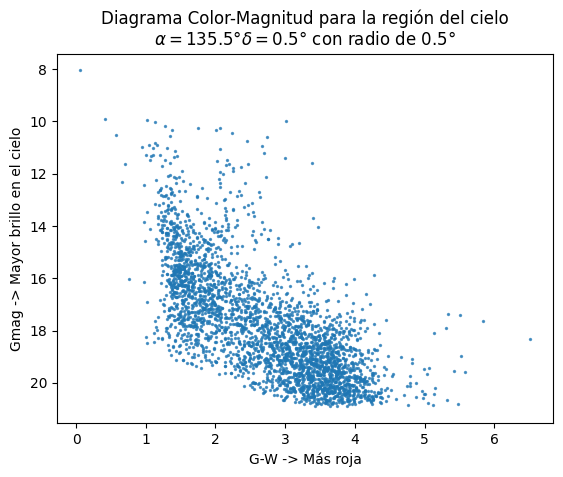

In [ ]:
plt.scatter(df['G-W'], df['Gmag'], s=2, alpha=0.7)
plt.title('Diagrama Color-Magnitud para la región del cielo\n'+ r'$\alpha=135.5$°$\delta=0.5$° con radio de 0.5°')
plt.ylabel('Gmag -> Mayor brillo en el cielo')
plt.xlabel('G-W -> Más roja')
plt.gca().invert_yaxis()
plt.savefig('cmd_1.png')
plt.show()